<div style="font-size:80%">

# Peri-Stimulus Time Histogram (PSTH)

## 概要

**Peri-Stimulus Time Histogram（PSTH）** は、神経活動（スパイク）を外的イベント（刺激提示や行動など）に時間整列し、イベント前後の平均的な発火率を可視化・定量化する解析手法である。多くの試行にわたるスパイク時刻を一定の時間幅でビン分割し、イベント時刻との相対時間でヒストグラムを作成することで、神経応答の時間構造を明らかにする。

---

## 計算手順

1. **スパイク時刻の取得**  
   全試行における神経スパイク発火時刻を `spike_times` に格納する。

2. **イベント時刻の指定**  
   各試行の基準イベント（例：刺激提示）時刻を `event_times` に指定する。

3. **整列処理（アラインメント）**  
   各イベントに対しスパイク時刻を整列（`spike_times - event_time`）し、指定された時間窓内（例：-0.5秒〜+1.0秒）のスパイクを抽出する。

4. **ビン分割とスパイクカウント**  
   ビン幅 `bin_size`（例：10 ms）で時間軸を分割し、各ビンに入るスパイク数をヒストグラムでカウントする。

5. **平均発火率への変換**  
   試行数で割り、1試行あたりの平均スパイク発火率（Hz）に変換する：

$$
\text{PSTH}_{\text{Hz}} = \frac{\text{Spike Count}}{\text{Number of Trials} \times \text{Bin Width}}
$$



---

## パラメータの説明

| 変数名       | 内容                                                                 |
|------------|----------------------------------------------------------------------|
| `bin_size` | ビン幅（秒）。例：`0.01` は 10ms ごとのスパイクカウント。           |
| `window`   | 時間窓（秒）。例：`[-0.5, 1.0]` は刺激前0.5秒〜後1.0秒を対象にする。  |
| `spike_times` | スパイク発火時刻（ランダムに生成）。実験データに置き換える。     |
| `event_times` | イベント時刻（例：刺激提示）。これを基準にスパイクを整列する。    |

---

## 解釈と応用

- PSTH は、特定のイベントに対する神経応答の**時間的変化**を明確にする。
- 明確なピークは、**一過性かつ一貫した応答**を示す。
- 持続的な活動や応答の欠如も可視化可能。
- シングルユニットやマルチユニット、光遺伝学刺激など多様な解析に利用される。

---

## 注意点

- **ビン幅**は時間分解能とノイズのトレードオフを調整する。
- **試行数**が少ないと平均化の信頼性が低くなる。
- 統計的有意性を検定するには、ベースラインとの比較が必要。

---

## 参考文献

- Gerstein, G. L., & Perkel, D. H. (1969). *Simultaneously recorded trains of action potentials: analysis and functional interpretation*. Science, 164(3881), 828–830.
- Dayan, P., & Abbott, L. F. (2001). *Theoretical Neuroscience*. MIT Press.
- https://www.tdt.com/docs/sdk/offline-data-analysis/offline-data-python/examples/03_RasterPSTH/

<br>
<br>
<br>

---

# PETH(Peri-Event Time Histogram) 
- 刺激だけではなく、行動も含めた意味でPeri-Event Time Histgramということもある。
- 今回はPETHとして関数を作成している。
- 関数の説明は以下

入力

| 変数名                    | 型                      | 説明                                                                  |
| ---------------------- | ---------------------- | ------------------------------------------------------------------- |
| `spike_times`          | `np.ndarray`           | 全スパイク時刻の配列（単位：秒）。すべてのトライアルを通したスパイク。                                 |
| `event_times`          | `np.ndarray`           | 各試行の基準イベント（刺激等）の時刻（単位：秒）。                                           |
| `bin_size`             | `float`                | PSTHのビン幅（単位：秒）。例：0.05なら50 msごとにスパイクを数える。                            |
| `time_window`          | `list[float, float]`   | 各イベント前後の解析時間範囲（例：\[-1, 1] は -1秒から+1秒）。                              |



出力



| 変数名                    | 型                      | 説明                                                                  |
| ---------------------- | ---------------------- | ------------------------------------------------------------------- |
| `peth['trial']`        | `np.ndarray[int]`      | トライアル番号の配列（1, 2, ..., n\_trials）。                                   |
| `peth['bins']`         | `np.ndarray[float]`    | ビンの境界配列（時間軸用）。                                                      |
| `peth['spike_counts']` | `np.ndarray[np.uint8]` | 各トライアル・ビンごとのスパイク数（符号なし8bit整数）。                                      |

</div>

In [1]:
# Basic
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import csv
import pickle

# SpikeInterface
import spikeinterface as si
import spikeinterface.extractors as se
from spikeinterface.preprocessing import get_motion_parameters_preset, get_motion_presets

# Local imports
import libs.utils.utils as utils
import libs.handle.dataset as dataset
import libs.analysis.spikes as spikes

c:\Users\shoya\code\tamagawa-neuro-training-shysgmt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def compute_behv_time(trials, event, procTeensy_to_imec): 
 
    event_grouped = event.groupby('trial') 
    target_trials = trials['trial'].dropna().astype(int).values 
 
    ready_time = np.zeros(len(target_trials)) 
    stim_time = np.zeros(len(target_trials)) 
    choice_time = np.zeros(len(target_trials)) 
    outcome_time = np.zeros(len(target_trials)) 
 
    for i in range(len(target_trials)): 
 
        df = event_grouped.get_group(target_trials[i]) 
         
        tf = (df['state'].isin([3, 4])) & (df['state'].shift(1).isin([2])) 
        row = df[tf]['row_index'].values 
        ready_time[i] = procTeensy_to_imec[row[0]] 
         
        tf = (
            df['state'].isin([3, 4])
            & df['column_name_changed'].isin(['binary_photodiode'])
        )
        row = df[tf]['row_index'].values 
        stim_time[i] = procTeensy_to_imec[row[0]] 
 
        tf = (
            df['state'].isin([5, 6, 7, 8])
            & df['state'].shift(1).isin([3, 4])
        )
        row = df[tf]['row_index'].values 
        choice_time[i] = procTeensy_to_imec[row[0]] 
         
        tf = (
            df['column_name_changed'].isin(['dispenser'])
            & (df['dispenser'] == 1)
        )
        
        if tf.any(): 
            row = df[tf]['row_index'].values 
            outcome_time[i] = procTeensy_to_imec[row[0]] 
        else: 
            outcome_time[i] = np.nan 
         
    behavior_time = { 
        'trial': target_trials, 
        'ready': ready_time, 
        'stim': stim_time, 
        'choice': choice_time, 
        'outcome': outcome_time 
    } 
         
    return behavior_time

In [3]:
# Generate a session object
session_dir = r"E:\RSS060_260804_160648"
session = dataset.Session(session_dir)

In [4]:
# Extract dataset of target probe
i_imec = 0
session.add_trials()
session.add_event()
session.add_sorting_analyzer(i_imec=i_imec)
session.add_procTeensy_to_imec(i_imec=i_imec)


Loading sorting_analyzer from E:\RSS060_260804_160648\spikeinterface\imec0\sorting_analyzer_dredge


In [12]:
trials = session.trials
event = session.event

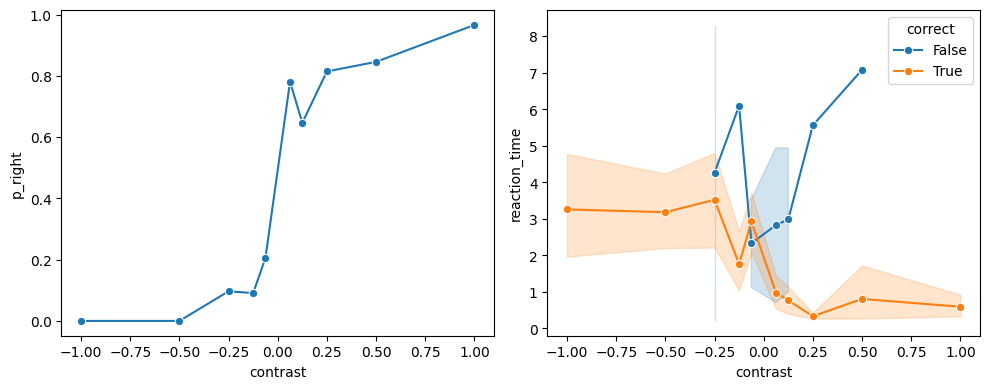

In [25]:
df = trials.copy()
df['pushsum'] = df['pc_left']+df['pc_right']
df['p_right'] = df['choice'].map({'left': 0, 'right': 1})

df['reaction_time'] = np.where(
    df['choice'] == 'left',
    df['rt_left'],
    df['rt_right']
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.lineplot(
    data=df,
    x='contrast',
    y='p_right',
    marker='o',
    errorbar=None,
)

plt.subplot(1, 2, 2)
sns.lineplot(
    data=df[df['pushsum']==1],
    x='contrast',
    y='reaction_time',
    hue='correct',
    marker='o',
)

plt.tight_layout()

In [5]:
# Extact sorrting analyzer
sorting = session.sorting_analyzer.sorting

In [ ]:
unit_ids = sorting.get_unit_ids()
procTeensy_to_imec = session.procTeensy_to_imec
sampling_rate = sorting.sampling_frequency

In [62]:
behv_time = compute_behv_time(trials, event, procTeensy_to_imec) 
behv_time.keys()

dict_keys(['trial', 'ready', 'stim', 'choice', 'outcome'])

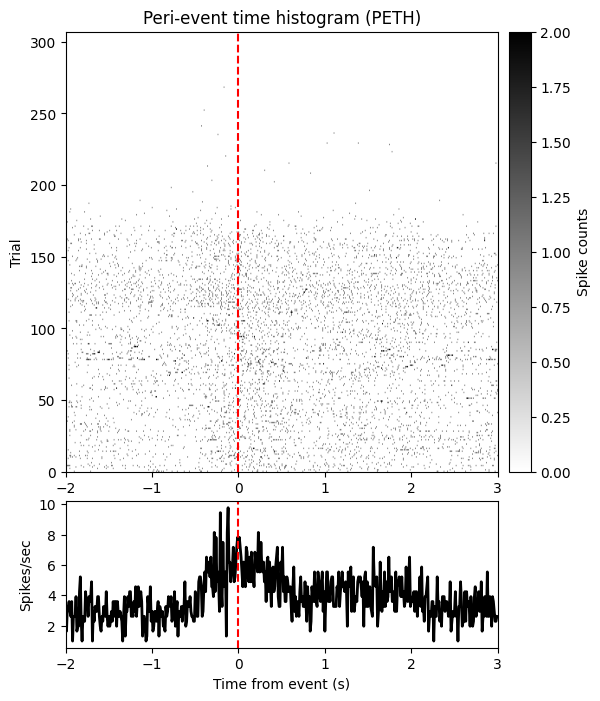

In [96]:
unit_id = unit_ids[2]
event_time = behv_time['choice']
spike_time = sorting.get_unit_spike_train(unit_id=unit_id)/sampling_rate

peth = spikes.compute_peth_array(
    spike_times=spike_time,
    event_times=event_time,
    bin_size=0.01,
    time_window=[-2, 3])

#print('Trials', len(peth['trial']))
#print(peth['trial'])
#print('Bins', len(peth['bins']))
#print(peth['bins'])
#print('Spike counts', np.shape(peth['spike_counts']))
#print(peth['spike_counts'])

spikes.plot_peth(peth)

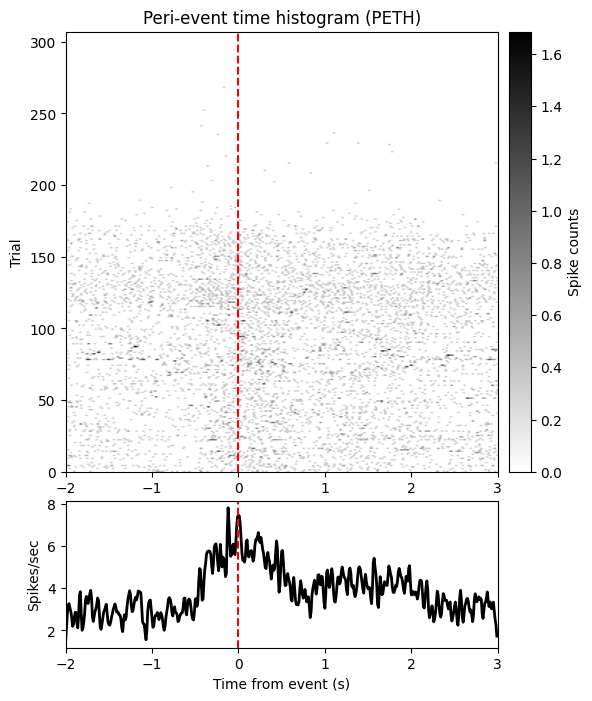

In [88]:
peth_smooth = spikes.compute_peth_smooth(peth, sigma_sec=0.01)
spikes.plot_peth(peth_smooth)

(-1.0, 2.0)

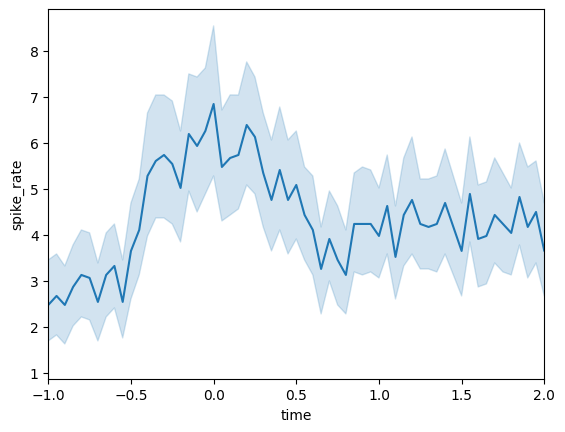

In [91]:
unit_id = unit_ids[2]
event_time = behv_time['choice']
spike_time = sorting.get_unit_spike_train(unit_id=unit_id)/sampling_rate

peth = spikes.compute_peth_array(
    spike_times=spike_time,
    event_times=event_time,
    bin_size=0.05,
    time_window=[-2, 3])

peth_smooth = spikes.compute_peth_smooth(peth, sigma_sec=0.01)
peth_fr = spikes.compute_peth_fr(peth_smooth)

peth_df = spikes.peth_to_longdf(peth_fr)

sns.lineplot(
    data=peth_df, 
    x='time', 
    y='spike_rate', 
)
plt.xlim([-1, 2])

In [92]:
trial_target = trials[['trial', 'stim', 'choice', 'correct']].dropna()
df = peth_df.merge(trial_target, on='trial', how='left')
df

,time,trial,spike_rate,stim,choice,correct
0,-2.00,1,0.000000,right,right,True
1,-1.95,1,0.000000,right,right,True
2,-1.90,1,0.000000,right,right,True
3,-1.85,1,0.000000,right,right,True
4,-1.80,1,0.000000,right,right,True
...,...,...,...,...,...,...
30695,2.75,307,0.000000,left,left,True
30696,2.80,307,0.000075,left,left,True
30697,2.85,307,19.999851,left,left,True
30698,2.90,307,0.000149,left,left,True


(-1.0, 3.0)

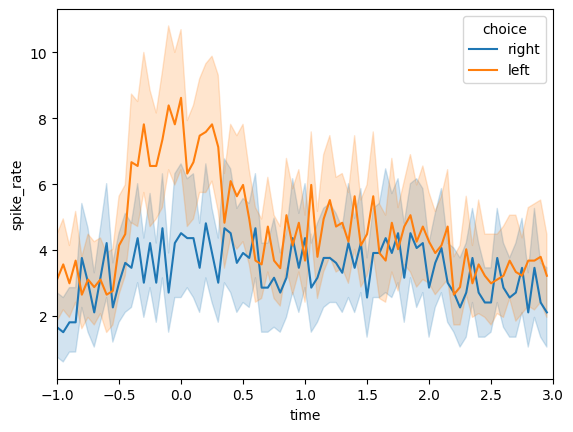

In [94]:
 #Long-formatはseabornと相性がいい。
sns.lineplot(
    data=df, 
    x='time', 
    y='spike_rate',
    hue='choice',
)
plt.xlim([-1, 3])

### Codeをまとめる

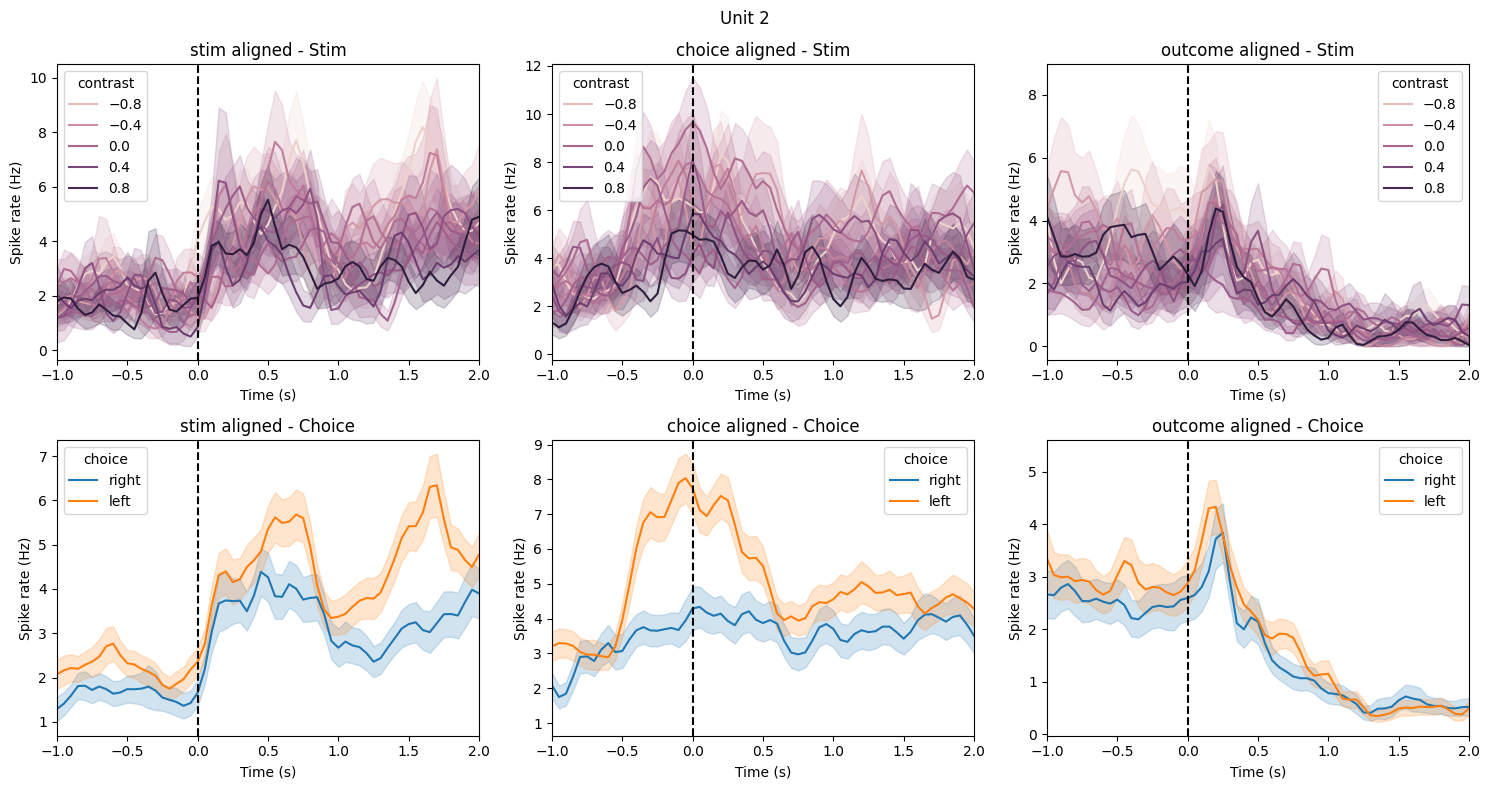

In [136]:
unit_id = unit_ids[2]
spike_time = sorting.get_unit_spike_train(unit_id=unit_id) / sampling_rate

events = {
    'stim': behv_time['stim'],
    'choice': behv_time['choice'],
    'outcome': behv_time['outcome']
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for j, (event_name, event_time) in enumerate(events.items()):

    peth = spikes.compute_peth_array(
        spike_times=spike_time,
        event_times=event_time,
        bin_size=0.05,
        time_window=[-2, 3]
    )

    peth_smooth = spikes.compute_peth_smooth(peth, sigma_sec=0.05)
    peth_fr = spikes.compute_peth_fr(peth_smooth)
    peth_df = spikes.peth_to_longdf(peth_fr)

    trial_target = trials[['trial', 'stim', 'contrast', 'choice', 'correct']].dropna()
    df = peth_df.merge(trial_target, on='trial', how='left')

    # Split by stimulus
    sns.lineplot(
        data=df,
        x='time',
        y='spike_rate',
        hue='contrast',
        errorbar='se',
        ax=axes[0, j]
    )
    axes[0, j].set_title(f'{event_name} aligned - Stim')

    # Split by choice
    sns.lineplot(
        data=df,
        x='time',
        y='spike_rate',
        hue='choice',
        errorbar='se',
        ax=axes[1, j]
    )
    axes[1, j].set_title(f'{event_name} aligned - Choice')

for ax in axes.flat:
    ax.set_xlim([-1, 2])
    ax.axvline(0, color='k', linestyle='--')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Spike rate (Hz)')

plt.suptitle(f'Unit {unit_id}')
plt.tight_layout()
plt.show()

In [138]:
# Compute PETH dict
# spike_time, event_timeなどから、peth_fr, petf_drを計算してまとめる関数
def compute_peth_dict(spike_time, event_time, bin_size=0.05, time_window=[-1, 1.5], sigma_sec=0.05):
    peth = spikes.compute_peth_array(
    spike_times=spike_time,
        event_times=event_time,
        bin_size=bin_size,
        time_window=time_window)

    peth_smooth = spikes.compute_peth_smooth(peth, sigma_sec=sigma_sec)
    peth_fr = spikes.compute_peth_fr(peth_smooth)
    peth_df = spikes.peth_to_longdf(peth_fr)
    
    PETH = {
        'fr': peth_fr,
        'df': peth_df
    }
    
    return PETH

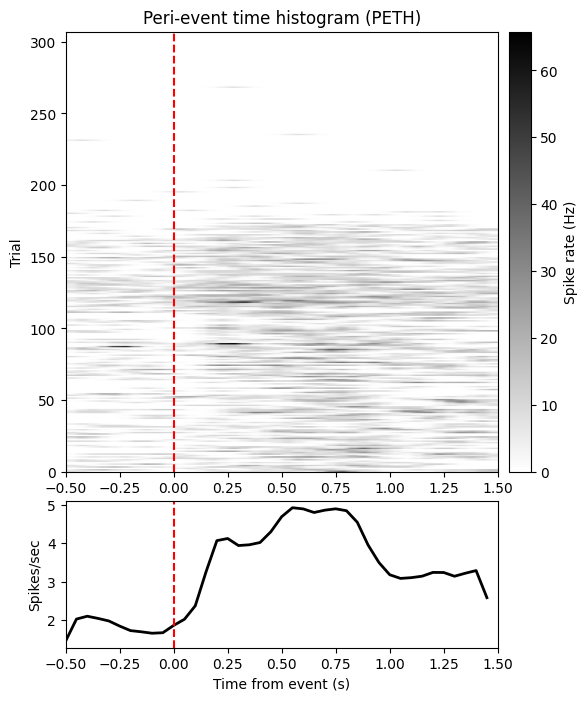

Text(0.5, 1.0, 'Unit 2 - PETH for Ready Event')

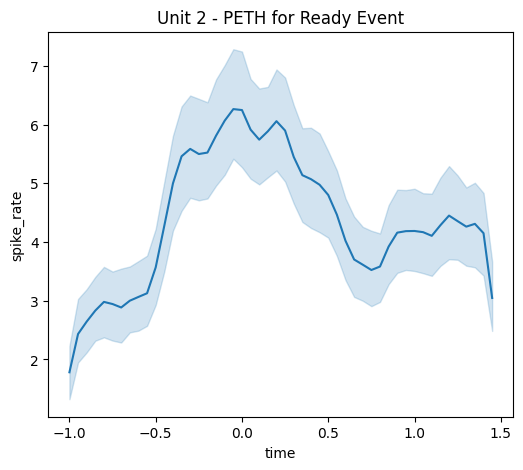

In [139]:

unit_id = unit_ids[2]
spike_time = sorting.get_unit_spike_train(unit_id=unit_id)/sampling_rate

bin_size = 0.05
sigma_sec = 0.05
PETH_ready = compute_peth_dict(spike_time, behv_time['ready'], bin_size=bin_size, time_window=[-0.5, 1.5], sigma_sec=sigma_sec)
PETH_choice = compute_peth_dict(spike_time, behv_time['choice'], bin_size=bin_size, time_window=[-1, 1.5], sigma_sec=sigma_sec)


# Plotting PETH results
# plot PETH fr
spikes.plot_peth(PETH_ready['fr'])

# plot PETH df
plt.figure(figsize=(6, 5))
sns.lineplot(
    data=PETH_choice['df'], 
    x='time', 
    y='spike_rate', 
)
plt.title(f'Unit {unit_id} - PETH for Ready Event')

<div style="font-size:80%">

## Z-score

### 定義
Z-score は、あるデータ点が平均からどれだけ離れているかを **標準偏差の単位で表す**統計量です。

\[
z = \frac{x - \mu}{\sigma}
\]

- \( x \)：観測値  
- \( \mu \)：全体の平均  
- \( \sigma \)：標準偏差  

---

### 意味と解釈
- \( z = 0 \)：平均と等しい  
- \( z = 1 \)：平均より 1 標準偏差上  
- \( z = -2 \)：平均より 2 標準偏差下  

---

### 用途
- 異なるスケールのデータを標準化して比較する  
- 異常値（アウトライヤー）の検出  
- 正規分布に従うデータの確率評価  
- 神経活動のベースラインと刺激後の比較に使用（例：PETH）

---

### 神経科学での例
スパイク発火率の時間変化において、ベースライン(例：刺激提示前)の平均と標準偏差をもとに、刺激後の活動の変化を Z-score で評価：

```python
z = (spike_rate - baseline_mean) / baseline_std
```

Z-score によって、神経活動の有意な変化を定量的に評価可能になります。

</div>

Baseline average spike rate: 3.9884179466510883
Baseline standard deviation of spike rate: 6.197368569422634


Text(0, 0.5, 'Z-score of Spike Rate')

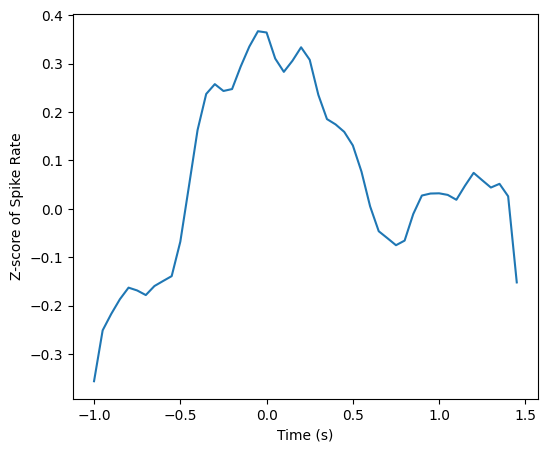

In [100]:
# Compute z-score of spike rate
df = PETH_ready['df']
avg = df.loc[(df['time']>=0) & (df['time']<1), 'spike_rate'].mean()
std = df.loc[(df['time']>=0) & (df['time']<1), 'spike_rate'].std()
base_line = {
    'avg': avg,
    'std': std
}
print('Baseline average spike rate:', avg)
print('Baseline standard deviation of spike rate:', std)

fr = PETH_choice['fr']
bins = fr['bins']
spks = fr['spike_rate']
z_score = (spks - base_line['avg']) / base_line['std']

plt.figure(figsize=(6, 5))
sns.lineplot(
    x=bins[0:-1],
    y=z_score.mean(axis=0),
)
plt.xlabel('Time (s)')
plt.ylabel('Z-score of Spike Rate')

<div style="font-size:80%">

# 神経活動に基づくニューロンのクラスタリング

---

## クラスタリングとは？

神経活動に基づくクラスタリングとは、**スパイク発火パターンや応答特性が似ているニューロン同士を自動的にグループ分けする**手法です。  
これは、**神経回路の機能的構造や役割を理解する**うえで重要な解析です。

---

## 一般的な流れ

### 1. **特徴抽出（Feature Extraction）**

各ニューロンについて、以下のような特徴量を数値化します：

- 発火率（firing rate）
- PSTH / PETH（刺激に対する時間的発火パターン）
- チューニング特性（例：方向選好性、感覚応答強度）
- スパイク波形や応答遅延

→ 各ニューロンを高次元ベクトルとして表現します。

---

### 2. **次元削減（Dimensionality Reduction）※任意**

視覚化やクラスタ分離のために、次元を2〜3次元に圧縮します：

- PCA（主成分分析）
- t-SNE
- UMAP など

---

### 3. **クラスタリング（Clustering）**

教師なし学習アルゴリズムで類似ニューロンを自動分類します：

- K-means
- 階層クラスタリング
- Gaussian Mixture Models（GMM）
- DBSCAN（密度に基づくクラスタリング）

---

### 4. **クラスタの解釈**

各クラスタが何を意味するのかを評価します：

- 刺激応答の違い（例：視覚 vs 聴覚）
- 動作準備 vs 実行などの機能的分化
- 脳領域やレイヤーとの対応
- 学習や注意状態による変化

---

## なぜクラスタリングするのか？

- **機能的ニューロンタイプの識別**（例：選好性のある vs ない細胞）
- **神経集団の構造把握**やパターン発見
- **状態変化や学習効果の評価**
- データの次元圧縮と可視化

---

## 補足

この手法は「教師なし学習（unsupervised learning）」の一例であり、**あらかじめ正解ラベルが存在しない**データの構造を明らかにする目的で使われます。

スパイク列だけでなく、**カルシウムイメージングやfMRIなど他の神経データ**にも応用可能です。

</div>

In [101]:
# Function to compute z-score from PETH DataFrame
def compute_base_line(event_time, spike_time, bins_size=0.05, time_window=[0, 1], sigma_sec=0.05, target_time_window=[0, 1]):

    PETH = compute_peth_dict(spike_time, event_time, bins_size, time_window, sigma_sec)
    df = PETH['df']

    df = PETH['df']
    avg = df.loc[(df['time']>=target_time_window[0]) & (df['time']<target_time_window[1]), 'spike_rate'].mean()
    std = df.loc[(df['time']>=target_time_window[0]) & (df['time']<target_time_window[1]), 'spike_rate'].std()
    base_line = {
        'avg': avg,
        'std': std
    }
    
    return base_line


# Function to compute z-score from PETH DataFrame
def compute_z_score(event_time, spike_time, bins_size=0.05, time_window=[-1, 1.5], sigma_sec=0.05, base_line=[0, 1], target_time_window=[0, 1]):

    PETH = compute_peth_dict(spike_time, event_time, bins_size, time_window, sigma_sec)
    fr = PETH['fr']
    bins = fr['bins']

    z_score = (fr['spike_rate'] - base_line['avg']) / base_line['std']
    
    # Filter
    tf = (bins[0:-1]>=target_time_window[0])&(bins[0:-1]<target_time_window[1])
    z_score_target = z_score[:, tf]
    mean_z_score = z_score_target.mean(axis=0)
    
    return mean_z_score

In [102]:
unit_id = unit_ids[100]
spike_time = sorting.get_unit_spike_train(unit_id=unit_id)/sampling_rate

event_time = behv_time['ready']
base_line = compute_base_line(event_time, spike_time, bins_size=0.05, time_window=[-0.5, 1.5], sigma_sec=0.05, target_time_window=[0, 1])

event_time = behv_time['choice']
mean_z_socre = compute_z_score(event_time, spike_time, bins_size=0.05, time_window=[-1, 1.5], sigma_sec=0.05, base_line=base_line, target_time_window=[0, 1])

In [119]:
bins_size = 0.05
sigma_sec=0.01

# Initialize arrays to store z-scores for each unit and event type
col_length = 14  # Number of bins in the PETH
z_score_stim = np.zeros((len(unit_ids), col_length))
z_score_choice = np.zeros((len(unit_ids), col_length))
z_score_outcome = np.zeros((len(unit_ids), col_length))

# Compute z-score for each unit and event type
for i in range(0, len(unit_ids)):
    unit_id = unit_ids[i]
    spike_time = sorting.get_unit_spike_train(unit_id=unit_id)/sampling_rate
    
    event_time = behv_time['ready']
    base_line = compute_base_line(event_time, spike_time, bins_size=bin_size, time_window=[-0.5, 1], sigma_sec=sigma_sec, target_time_window=[-0.2, 0.5])
    
    event_time = behv_time['stim']
    z_score_stim[i, :] = compute_z_score(event_time, spike_time, bins_size=bin_size, time_window=[-0.5, 1], sigma_sec=sigma_sec, base_line=base_line, target_time_window=[-0.2, 0.5])
    
    event_time = behv_time['choice']
    z_score_choice[i, :] = compute_z_score(event_time, spike_time, bins_size=bin_size, time_window=[-0.5, 1], sigma_sec=sigma_sec, base_line=base_line, target_time_window=[-0.2, 0.5])
    
    event_time = behv_time['outcome']
    z_score_outcome[i, :] = compute_z_score(event_time, spike_time, bins_size=bin_size, time_window=[-0.5, 1], sigma_sec=sigma_sec, base_line=base_line, target_time_window=[-0.2, 0.5])
    
    if i % 10 == 0:
        print(f'Unit {i+1}/{len(unit_ids)}')


Unit 1/1171
Unit 11/1171
Unit 21/1171
Unit 31/1171
Unit 41/1171
Unit 51/1171
Unit 61/1171
Unit 71/1171
Unit 81/1171
Unit 91/1171
Unit 101/1171
Unit 111/1171
Unit 121/1171
Unit 131/1171
Unit 141/1171
Unit 151/1171
Unit 161/1171
Unit 171/1171
Unit 181/1171
Unit 191/1171
Unit 201/1171
Unit 211/1171
Unit 221/1171
Unit 231/1171
Unit 241/1171
Unit 251/1171
Unit 261/1171
Unit 271/1171
Unit 281/1171
Unit 291/1171
Unit 301/1171
Unit 311/1171
Unit 321/1171
Unit 331/1171
Unit 341/1171
Unit 351/1171
Unit 361/1171
Unit 371/1171
Unit 381/1171
Unit 391/1171
Unit 401/1171
Unit 411/1171
Unit 421/1171
Unit 431/1171
Unit 441/1171
Unit 451/1171
Unit 461/1171
Unit 471/1171
Unit 481/1171
Unit 491/1171
Unit 501/1171
Unit 511/1171
Unit 521/1171
Unit 531/1171
Unit 541/1171
Unit 551/1171
Unit 561/1171
Unit 571/1171
Unit 581/1171
Unit 591/1171
Unit 601/1171
Unit 611/1171
Unit 621/1171
Unit 631/1171
Unit 641/1171
Unit 651/1171
Unit 661/1171
Unit 671/1171
Unit 681/1171
Unit 691/1171
Unit 701/1171
Unit 711/1171
Uni

C:\Users\shoya\AppData\Local\Temp\ipykernel_44632\4025712312.py:25: RuntimeWarning: invalid value encountered in divide
  z_score = (fr['spike_rate'] - base_line['avg']) / base_line['std']
C:\Users\shoya\AppData\Local\Temp\ipykernel_44632\4025712312.py:25: RuntimeWarning: divide by zero encountered in divide
  z_score = (fr['spike_rate'] - base_line['avg']) / base_line['std']


Unit 981/1171
Unit 991/1171
Unit 1001/1171
Unit 1011/1171
Unit 1021/1171
Unit 1031/1171
Unit 1041/1171
Unit 1051/1171
Unit 1061/1171
Unit 1071/1171
Unit 1081/1171
Unit 1091/1171
Unit 1101/1171
Unit 1111/1171
Unit 1121/1171
Unit 1131/1171
Unit 1141/1171
Unit 1151/1171
Unit 1161/1171
Unit 1171/1171


In [120]:
tunning_vector = np.concat([z_score_stim, z_score_choice, z_score_outcome], axis=1)

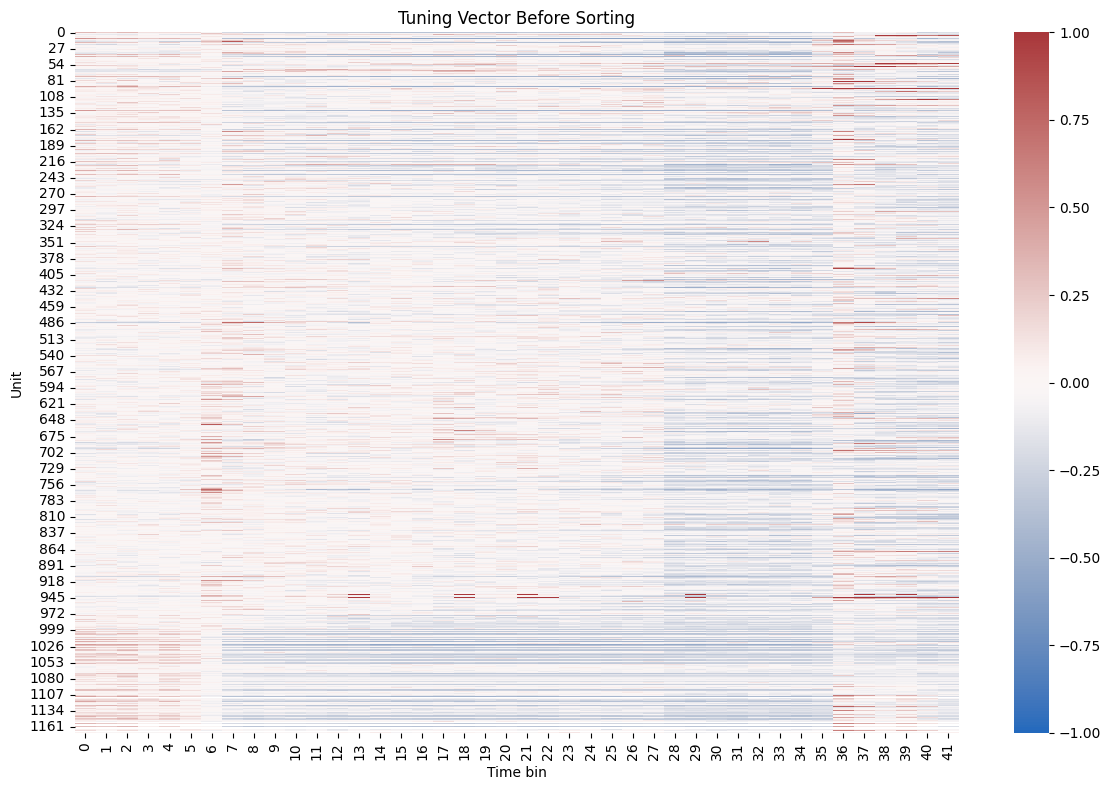

In [123]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    tunning_vector,
    cmap='vlag',
    center=0,
    vmin=-1,
    vmax=1,
)

plt.xlabel('Time bin')
plt.ylabel('Unit')
plt.title('Tuning Vector Before Sorting')
plt.tight_layout()
plt.show()

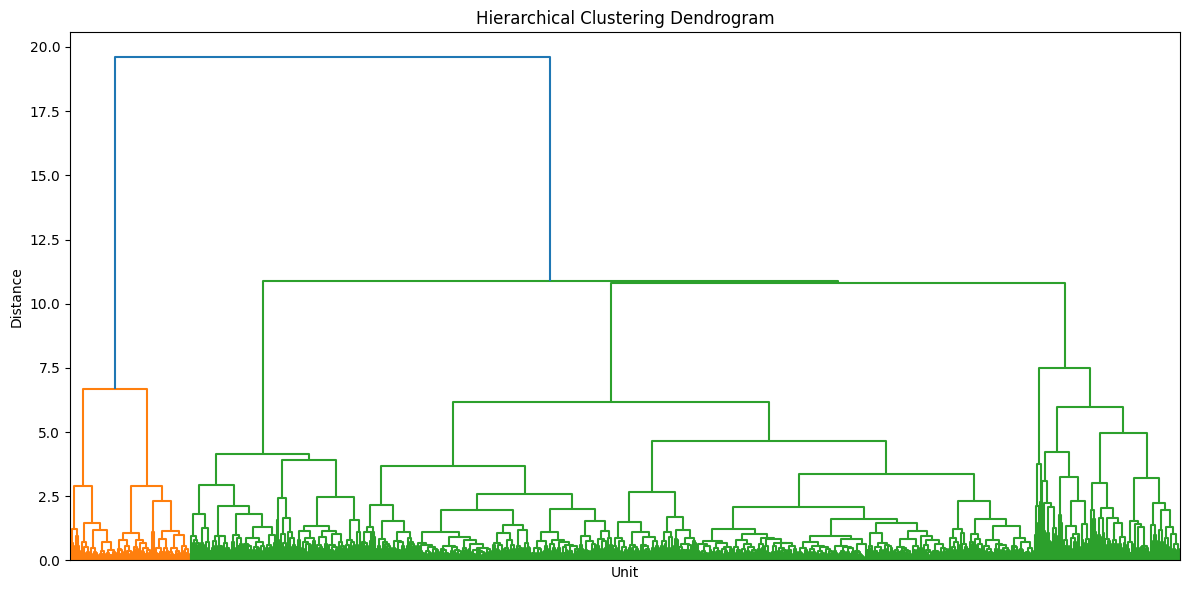

,UnitID,Cluster
0,0,1.0
1,1,3.0
2,2,3.0
3,3,3.0
4,4,3.0
...,...,...
1166,1166,3.0
1167,1167,1.0
1168,1168,NaN
1169,1169,3.0


In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Remove units containing NaN or extreme z-scores
z_threshold = 5

valid_mask = (
    ~np.isnan(tunning_vector).any(axis=1)
    & (np.abs(tunning_vector) <= z_threshold).all(axis=1)
)

tunning_vector_valid = tunning_vector[valid_mask]
unit_ids_valid = np.asarray(unit_ids)[valid_mask]

# PCA
n_components = min(20, tunning_vector_valid.shape[0], tunning_vector_valid.shape[1])
pca = PCA(n_components=n_components)
pca_result_valid = pca.fit_transform(tunning_vector_valid)

# Hierarchical clustering
Z = linkage(
    pca_result_valid,
    method='ward'
)

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    no_labels=True
)

plt.xlabel('Unit')
plt.ylabel('Distance')
plt.title('Hierarchical Clustering Dendrogram')
plt.tight_layout()
plt.show()

# Define number of clusters
n_clusters = 3

cluster_labels_valid = fcluster(
    Z,
    t=n_clusters,
    criterion='maxclust'
)

# Restore cluster labels to original unit IDs
cluster_all = np.full(len(unit_ids), np.nan)
cluster_all[valid_mask] = cluster_labels_valid

df = pd.DataFrame({
    'UnitID': unit_ids,
    'Cluster': cluster_all
})

df

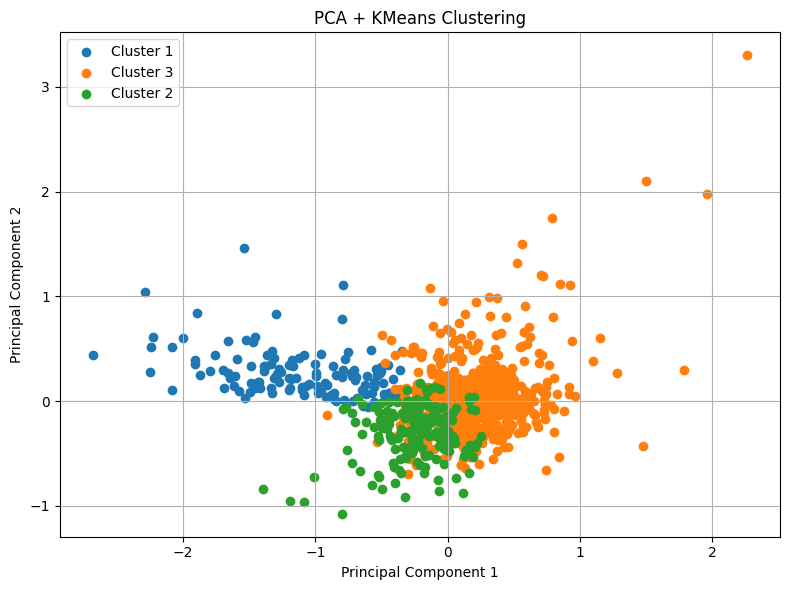

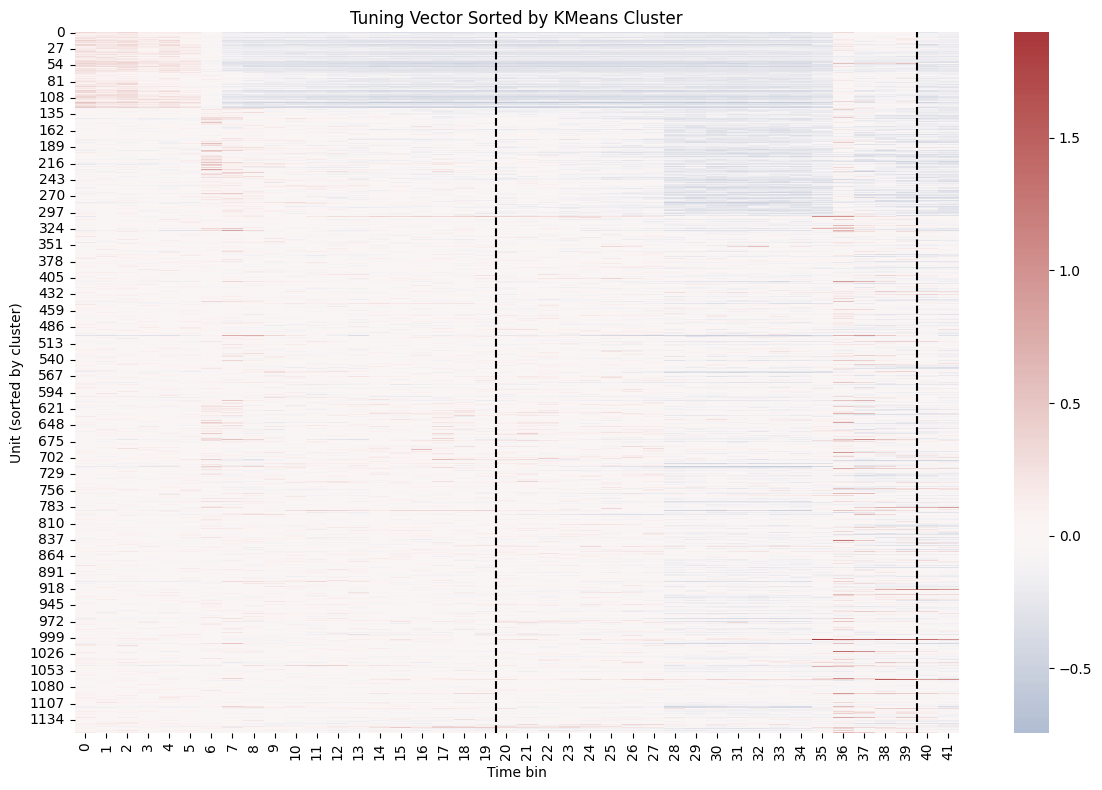

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame from the first 2 PCA components
pca_info = pd.DataFrame(
    pca_result_valid[:, :2],
    columns=['PC1', 'PC2']
)

pca_info['Cluster'] = cluster_labels_valid
pca_info['UnitID'] = unit_ids_valid

# PCA plot
plt.figure(figsize=(8, 6))

for cluster_id in pca_info['Cluster'].unique():
    cluster_data = pca_info[pca_info['Cluster'] == cluster_id]
    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster_id}'
    )

plt.title('PCA + KMeans Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Sort units by cluster
sort_idx = np.argsort(cluster_labels_valid)
tunning_vector_sorted = tunning_vector_valid[sort_idx]

# Heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    tunning_vector_sorted,
    cmap='vlag',
    center=0
)

plt.axvline(20, color='k', linestyle='--')
plt.axvline(40, color='k', linestyle='--')

plt.xlabel('Time bin')
plt.ylabel('Unit (sorted by cluster)')
plt.title('Tuning Vector Sorted by KMeans Cluster')
plt.tight_layout()
plt.show()

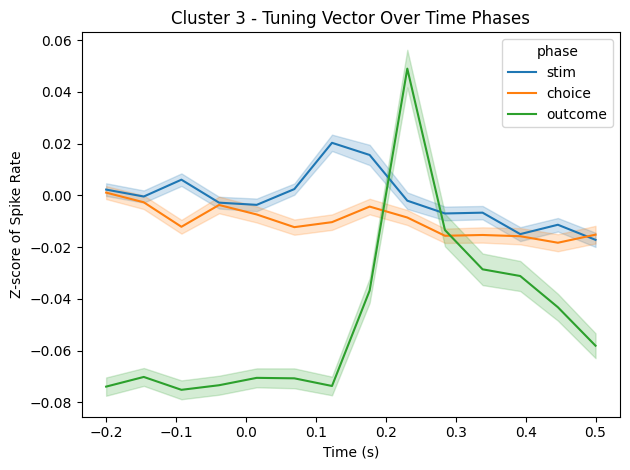

In [132]:
cluster_id = 3

# Get units belonging to this cluster
idx = np.where(cluster_labels_valid == cluster_id)[0]
cluster_vectors = tunning_vector_valid[idx]
cluster_unit_ids = unit_ids_valid[idx]

bin_num = 14
time_points = np.linspace(-0.2, 0.5, bin_num)
phase_dfs = []
phases = ['stim', 'choice', 'outcome']

# Process each phase
for i, phase in enumerate(phases):
    start = i * bin_num
    end = start + bin_num

    df_part = pd.DataFrame(cluster_vectors[:, start:end])
    df_part['unit_id'] = cluster_unit_ids

    df_long = df_part.melt(
        id_vars='unit_id',
        var_name='bin',
        value_name='value'
    )

    df_long['time'] = df_long['bin'].astype(int).map(
        dict(enumerate(time_points))
    )
    df_long['phase'] = phase

    phase_dfs.append(
        df_long[['unit_id', 'phase', 'time', 'value']]
    )

df_all_long = pd.concat(phase_dfs, ignore_index=True)

# Plot
sns.lineplot(
    data=df_all_long,
    x='time',
    y='value',
    hue='phase',
    estimator=np.mean,
    errorbar='se'
)

plt.ylabel('Z-score of Spike Rate')
plt.xlabel('Time (s)')
plt.title(f'Cluster {cluster_id} - Tuning Vector Over Time Phases')
plt.tight_layout()

   unit_id phase  time     value
0        0  stim   0.0  0.098002
1        1  stim   0.0  0.177363
2        2  stim   0.0  0.165797
3        3  stim   0.0 -0.026898
4        4  stim   0.0 -0.334320


C:\Users\Sugimoto\AppData\Local\Temp\ipykernel_46472\4031003196.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


<Axes: xlabel='time', ylabel='value'>

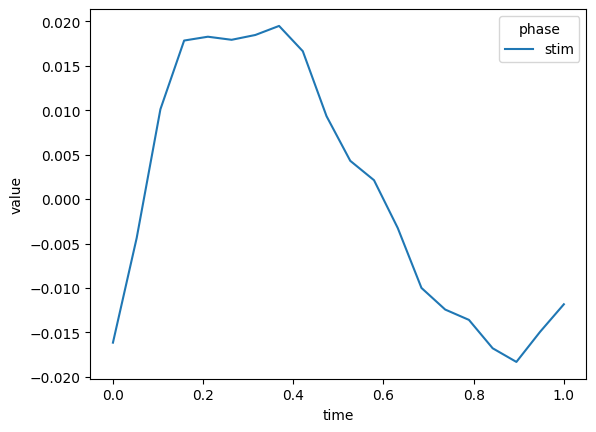

In [30]:
# 0–1秒を20分割した時間軸
time_points = np.linspace(0, 1, 20)

# 最初の20列（stim）
df_stim = pd.DataFrame(tunning_vector[:, :20])
df_stim['unit_id'] = df_stim.index

# 縦長に変換（long-format）
df_long = df_stim.melt(id_vars='unit_id', var_name='bin', value_name='value')

# 時間列を追加（binは0〜19が繰り返されるので、それをtimeに変換）
df_long['time'] = df_long['bin'].astype(int).map(dict(enumerate(time_points)))

# phase列を追加（すべてstim）
df_long['phase'] = 'stim'

# 整理
df_long = df_long[['unit_id', 'phase', 'time', 'value']]

# 表示
print(df_long.head())
# 表示
sns.lineplot(
    data=df_long, 
    x='time', 
    y='value', 
    hue='phase', 
    ci=None
)